# Mini-Project: House Price Prediction
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Regression on a housing dataset using Linear Regression.

Main goals:

- Run preprocessing and EDA on numeric housing features.
- Train a Linear Regression model and evaluate with MSE and R2.
- Examine predicted vs actual prices and the residuals.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/main/dataset/house_price_data.csv"

df = pd.read_csv(url)
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Preprocessing Checks

In [3]:
df.info()
print('\nMissing values:', df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
df.describe().round(2)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.00,1460.0,1201.00,1460.00,1460.00,1460.00,1460.00,1460.00,1452.00,1460.00,...,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.0
mean,730.50,56.9,70.05,10516.83,6.10,5.58,1971.27,1984.87,103.69,443.64,...,94.24,46.66,21.95,3.41,15.06,2.76,43.49,6.32,2007.82,180921.2
std,421.61,42.3,24.28,9981.26,1.38,1.11,30.20,20.65,181.07,456.10,...,125.34,66.26,61.12,29.32,55.76,40.18,496.12,2.70,1.33,79442.5
min,1.00,20.0,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,34900.0
25%,365.75,20.0,59.00,7553.50,5.00,5.00,1954.00,1967.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,2007.00,129975.0
50%,730.50,50.0,69.00,9478.50,6.00,5.00,1973.00,1994.00,0.00,383.50,...,0.00,25.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,163000.0
75%,1095.25,70.0,80.00,11601.50,7.00,6.00,2000.00,2004.00,166.00,712.25,...,168.00,68.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,214000.0
max,1460.00,190.0,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,5644.00,...,857.00,547.00,552.00,508.00,480.00,738.00,15500.00,12.00,2010.00,755000.0


## EDA

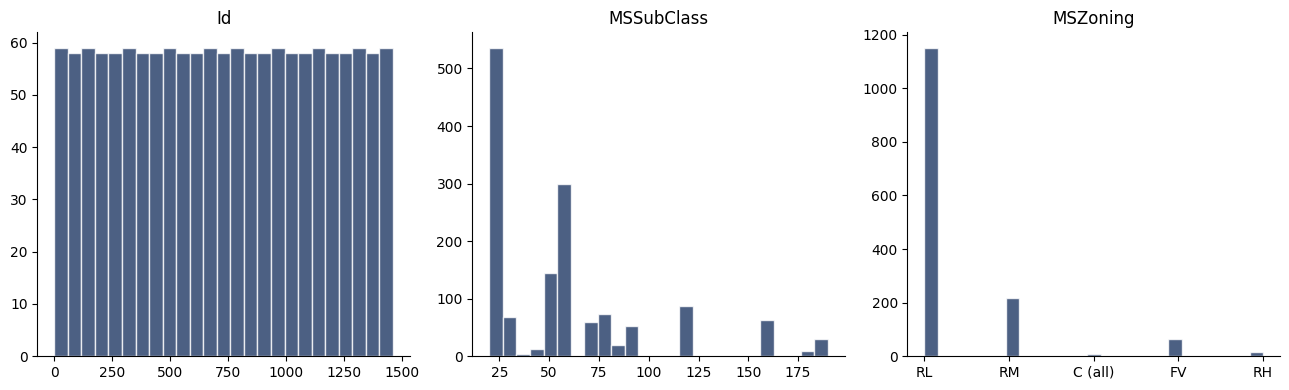

In [5]:
target_col = df.columns[-1]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, df.columns[:3]):
    ax.hist(df[col], bins=25, color='#1F3864', alpha=0.8, edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.show()

OverallQual      0.791
GrLivArea        0.709
GarageCars       0.640
GarageArea       0.623
TotalBsmtSF      0.614
1stFlrSF         0.606
FullBath         0.561
TotRmsAbvGrd     0.534
YearBuilt        0.523
YearRemodAdd     0.507
GarageYrBlt      0.486
MasVnrArea       0.477
Fireplaces       0.467
BsmtFinSF1       0.386
LotFrontage      0.352
WoodDeckSF       0.324
2ndFlrSF         0.319
OpenPorchSF      0.316
HalfBath         0.284
LotArea          0.264
BsmtFullBath     0.227
BsmtUnfSF        0.214
BedroomAbvGr     0.168
ScreenPorch      0.111
PoolArea         0.092
MoSold           0.046
3SsnPorch        0.045
BsmtFinSF2      -0.011
BsmtHalfBath    -0.017
MiscVal         -0.021
Id              -0.022
LowQualFinSF    -0.026
YrSold          -0.029
OverallCond     -0.078
MSSubClass      -0.084
EnclosedPorch   -0.129
KitchenAbvGr    -0.136
Name: SalePrice, dtype: float64


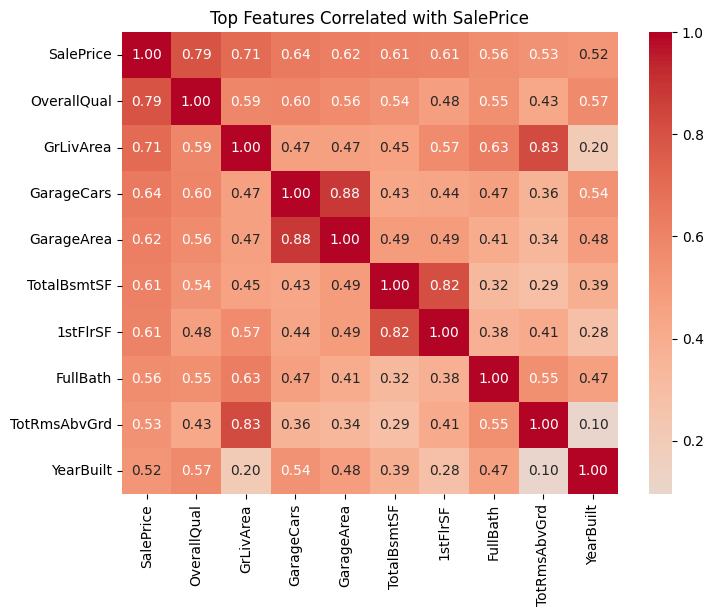

In [6]:
numeric_df = df.select_dtypes(include=np.number)

corr_with_target = (
    numeric_df.corr()[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

print(corr_with_target.round(3))

top_features = (
    numeric_df.corr()[target_col]
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    numeric_df[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Top Features Correlated with SalePrice')
plt.show()

**Observation:**
Features most strongly correlated with the target are the ones most likely to carry the largest coefficients once the model is trained — worth checking against the fitted weights later.

## Train-Test Split and Scaling

In [7]:
numeric_df = df.select_dtypes(include=np.number)
numeric_df = numeric_df.fillna(numeric_df.median())

X = numeric_df.drop(target_col, axis=1)
y = numeric_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}  Test: {X_test_scaled.shape}')

Train: (1168, 37)  Test: (292, 37)


## Training the Model

In [8]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f'MSE:  {mean_squared_error(y_test, y_pred):.2f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2:   {r2_score(y_test, y_pred):.4f}')

MSE:  1360121073.22
MAE:  23000.03
R2:   0.8227


## Predicted vs Actual

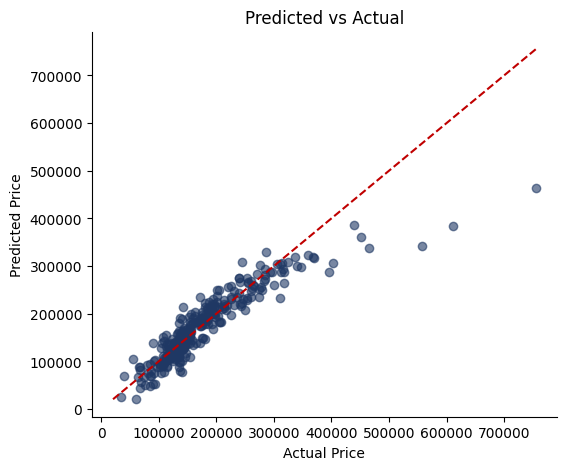

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred, alpha=0.6, color='#1F3864')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, '--', color='#C00000', lw=1.5)
ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')
ax.set_title('Predicted vs Actual')
plt.show()

## Residual Analysis

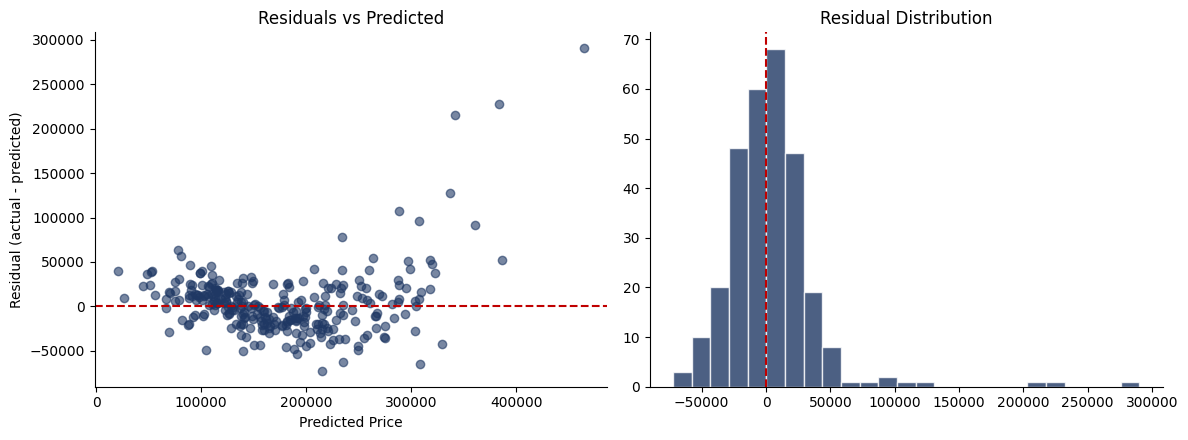

In [10]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_pred, residuals, alpha=0.6, color='#1F3864')
axes[0].axhline(0, color='#C00000', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=25, color='#1F3864', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='#C00000', linestyle='--')
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

**Observation:**
Residuals scattered without a clear pattern around 0 suggest the linear model isn't systematically over- or under-predicting in any price range. A funnel shape here would have suggested non-constant error variance across price levels.

## Feature Coefficients

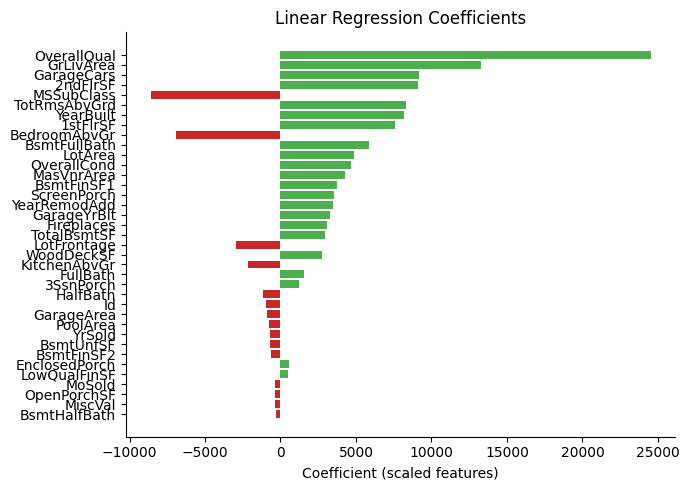

In [11]:
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2CA02C' if c > 0 else '#C00000' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.85)
ax.set_xlabel('Coefficient (scaled features)')
ax.set_title('Linear Regression Coefficients')
ax.invert_yaxis()
plt.tight_layout()
plt.show()